**Email Spam/Ham Classification using Naive Bayes and
KNN**


**Objectives:**
*   Build spam classifiers using Na¨ıve Bayes and KNN.
*   Compare Gaussian, Multinomial and Bernoulli Na¨ıve Bayes.
*  Study the effect of varying k.
*  Compare KDTree and BallTree

In [ ]:
#Importing all the packages
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB,
    BernoulliNB
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

In [ ]:
#Loading the dataset
df = pd.read_csv("spambase_csv.csv")

print("Dataset shape:", df.shape)
print("\nFirst five rows:")
print(df.head())

print("\nDataset information:")
print(df.info())

Dataset shape: (4601, 58)

First five rows:
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0             0.00     

In [ ]:
#Check for missing values in the dataset print("\nMissing values:")
print(df.isnull().sum().sum())

# If missing values are present, replace them using
# the median value of the corresponding numerical column.
for column in df.columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

print("\nMissing values after handling:",
      df.isnull().sum().sum())

0

Missing values after handling: 0


In [ ]:
#Separate features and target
X = df.drop("class", axis=1)
y = df["class"]

print("\nNumber of features:", X.shape[1])
print("Number of samples:", X.shape[0])


Number of features: 57
Number of samples: 4601



Class distribution:
class
0    2788
1    1813
Name: count, dtype: int64


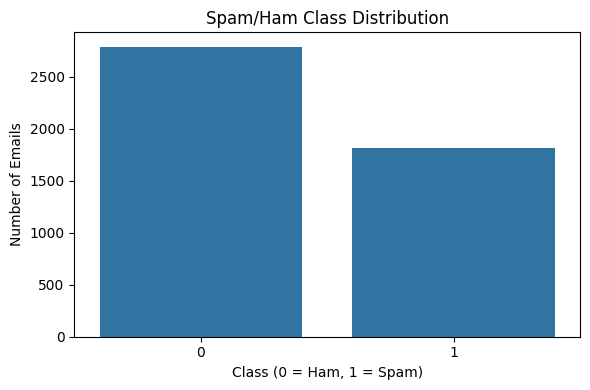

In [ ]:
#Exploratory Data Analysis
print("\nClass distribution:")
print(y.value_counts())

# Plot class distribution.
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Spam/Ham Class Distribution")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.ylabel("Number of Emails")
plt.tight_layout()
plt.show()

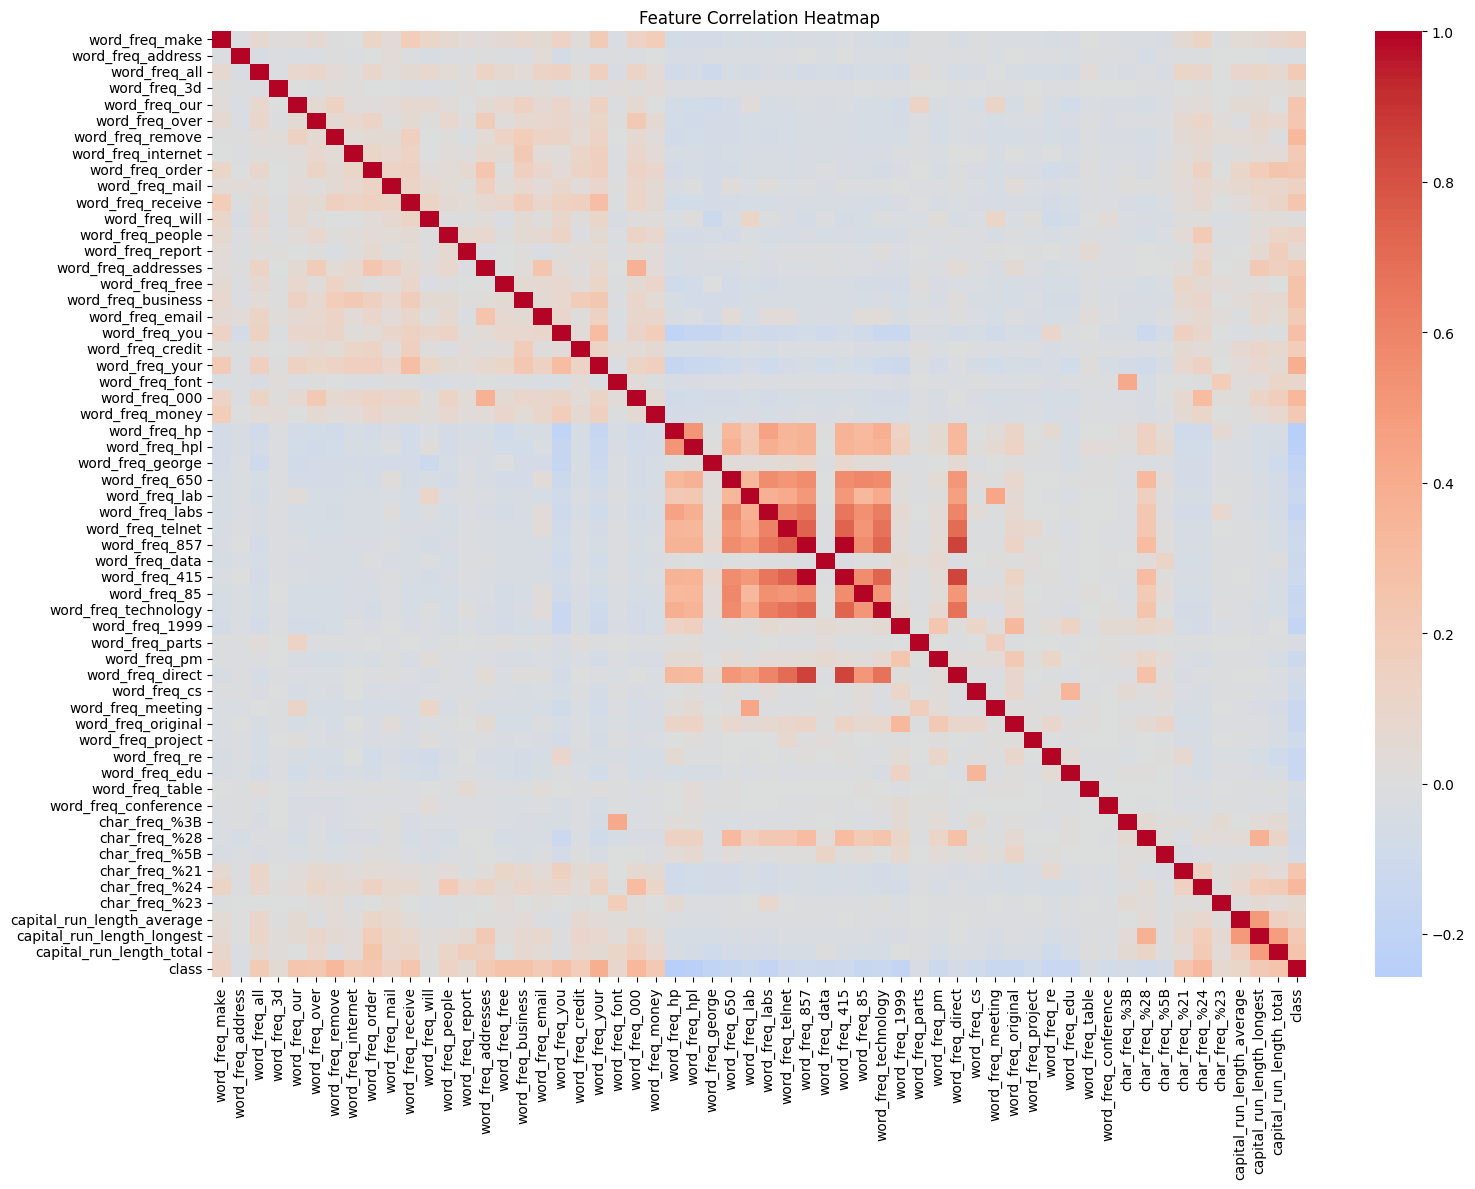

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

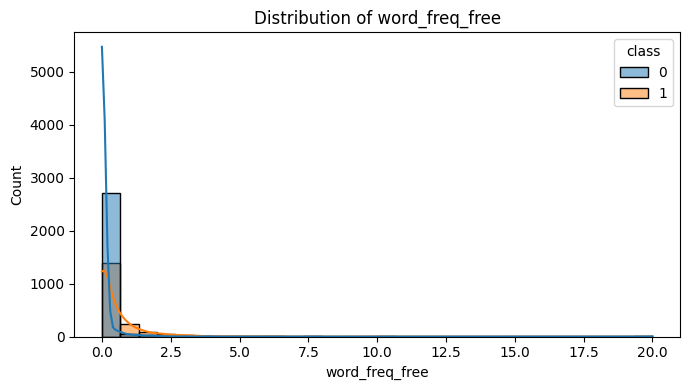

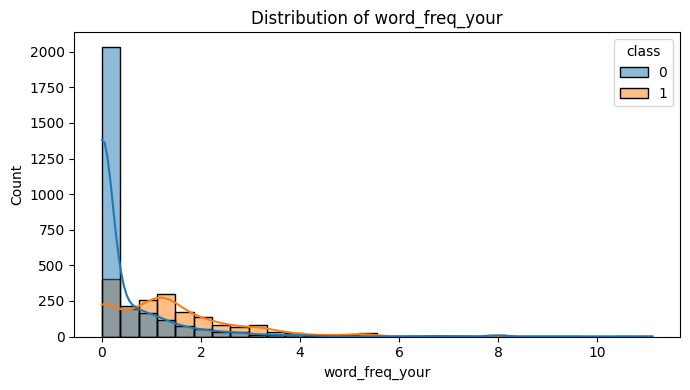

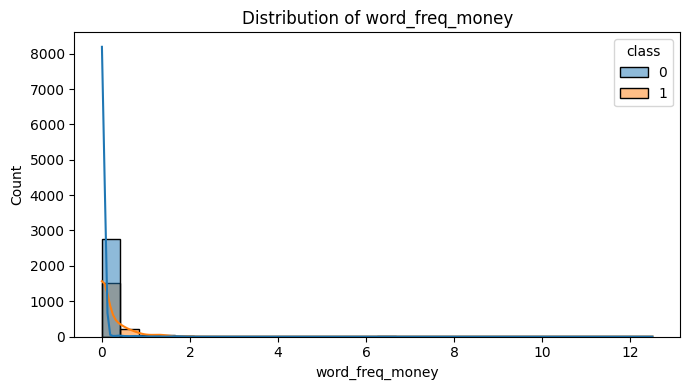

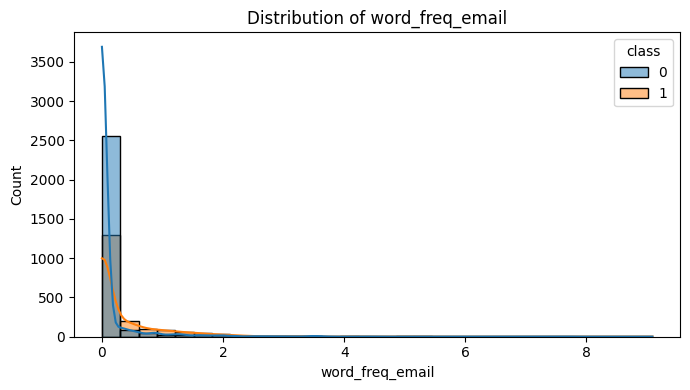

In [ ]:

# 6. Histograms of selected features

important_features = [
    "word_freq_free",
    "word_freq_your",
    "word_freq_money",
    "word_freq_email"
]

for feature in important_features:
    if feature in df.columns:
        plt.figure(figsize=(7, 4))
        sns.histplot(
            data=df,
            x=feature,
            hue="class",
            kde=True,
            bins=30
        )
        plt.title(f"Distribution of {feature}")
        plt.tight_layout()
        plt.show()

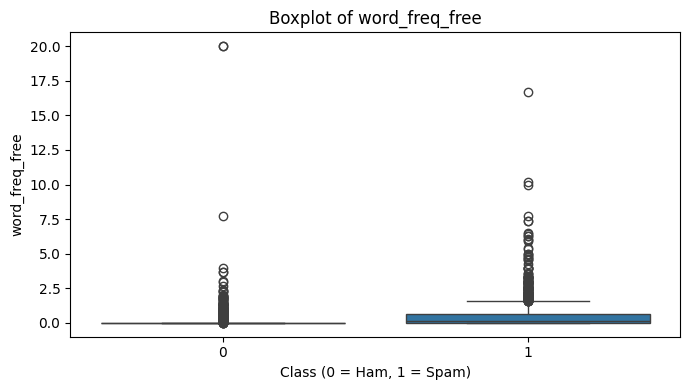

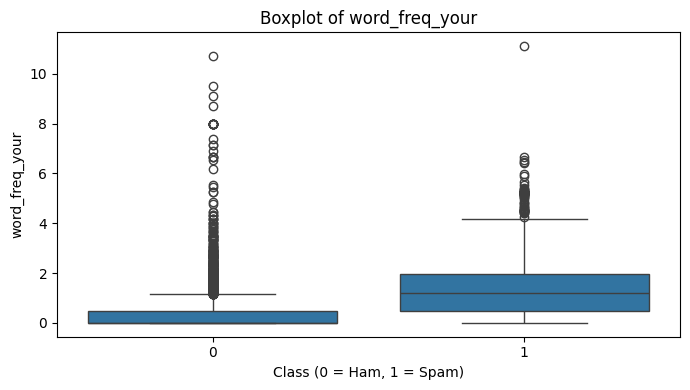

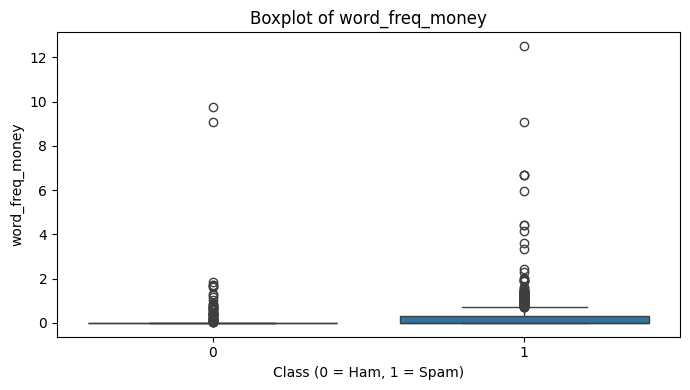

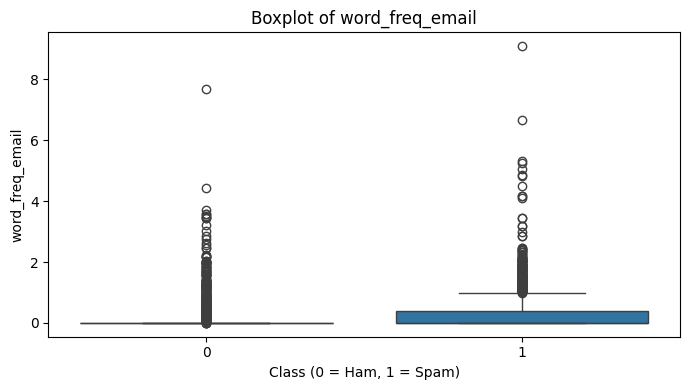

In [ ]:
# 7. Boxplots
for feature in important_features:
    if feature in df.columns:
        plt.figure(figsize=(7, 4))
        sns.boxplot(
            data=df,
            x="class",
            y=feature
        )
        plt.title(f"Boxplot of {feature}")
        plt.xlabel("Class (0 = Ham, 1 = Spam)")
        plt.tight_layout()
        plt.show()

In [ ]:

# 8. Train-test split
# Stratification keeps approximately the same proportion of spam and ham messages in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 3680
Testing samples: 921


In [ ]:

# 9. Feature scaling
# StandardScaler is used for Gaussian NB and KNN.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MinMaxScaler is useful for Multinomial and Bernoulli NB
# because these models work better with non-negative values.
minmax_scaler = MinMaxScaler()

X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

In [ ]:
# 10. Function for calculating evaluation metrics
def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Calculate the main classification metrics and
    return them as a dictionary.
    """

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

    return results

In [ ]:

# Naive Bayes Models

nb_results = []
nb_models = {}

# -------------------------
# Gaussian Naive Bayes
# -------------------------

start_time = time.perf_counter()

gaussian_nb = GaussianNB()
gaussian_nb.fit(X_train_scaled, y_train)

gaussian_train_time = time.perf_counter() - start_time

start_time = time.perf_counter()

gaussian_pred = gaussian_nb.predict(X_test_scaled)
gaussian_prob = gaussian_nb.predict_proba(X_test_scaled)[:, 1]

gaussian_prediction_time = time.perf_counter() - start_time

nb_results.append(
    evaluate_model(
        "Gaussian NB",
        y_test,
        gaussian_pred,
        gaussian_prob
    )
)

nb_models["Gaussian NB"] = gaussian_nb


# -------------------------
# Multinomial Naive Bayes
# -------------------------

start_time = time.perf_counter()

multinomial_nb = MultinomialNB()
multinomial_nb.fit(X_train_minmax, y_train)

multinomial_train_time = time.perf_counter() - start_time

start_time = time.perf_counter()

multinomial_pred = multinomial_nb.predict(X_test_minmax)
multinomial_prob = multinomial_nb.predict_proba(X_test_minmax)[:, 1]

multinomial_prediction_time = time.perf_counter() - start_time

nb_results.append(
    evaluate_model(
        "Multinomial NB",
        y_test,
        multinomial_pred,
        multinomial_prob
    )
)

nb_models["Multinomial NB"] = multinomial_nb


# -------------------------
# Bernoulli Naive Bayes
# -------------------------

start_time = time.perf_counter()

bernoulli_nb = BernoulliNB()
bernoulli_nb.fit(X_train_minmax, y_train)

bernoulli_train_time = time.perf_counter() - start_time

start_time = time.perf_counter()

bernoulli_pred = bernoulli_nb.predict(X_test_minmax)
bernoulli_prob = bernoulli_nb.predict_proba(X_test_minmax)[:, 1]

bernoulli_prediction_time = time.perf_counter() - start_time

nb_results.append(
    evaluate_model(
        "Bernoulli NB",
        y_test,
        bernoulli_pred,
        bernoulli_prob
    )
)

nb_models["Bernoulli NB"] = bernoulli_nb


# Convert results into a DataFrame.
nb_results_df = pd.DataFrame(nb_results)

print("\n================ Naive Bayes Comparison ================")
print(nb_results_df.to_string(index=False))


================ Naive Bayes Comparison ================
         Model  Accuracy  Precision   Recall       F1  ROC-AUC
   Gaussian NB  0.832790   0.714579 0.958678 0.818824 0.937612
Multinomial NB  0.895765   0.934853 0.790634 0.856716 0.961191
  Bernoulli NB  0.879479   0.868421 0.818182 0.842553 0.945674


In [ ]:
# KNN for different values of k
knn_results = []

k_values = [1, 3, 5, 7, 9, 11]

for k in k_values:

    # Standardized features are used because KNN is
    # distance-based.
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform",
        algorithm="auto"
    )

    start_time = time.perf_counter()

    knn.fit(X_train_scaled, y_train)

    train_time = time.perf_counter() - start_time

    start_time = time.perf_counter()

    pred = knn.predict(X_test_scaled)
    prob = knn.predict_proba(X_test_scaled)[:, 1]

    prediction_time = time.perf_counter() - start_time

    knn_results.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "Training Time": train_time,
        "Prediction Time": prediction_time
    })


knn_results_df = pd.DataFrame(knn_results)

print("\n================ KNN Comparison ================")
print(knn_results_df.to_string(index=False))


================ KNN Comparison ================
 k  Accuracy  Precision   Recall       F1  ROC-AUC  Training Time  Prediction Time
 1  0.899023   0.879213 0.862259 0.870654 0.892599       0.007077         0.404027
 3  0.897937   0.872576 0.867769 0.870166 0.936044       0.002364         0.269572
 5  0.907709   0.886111 0.878788 0.882434 0.950564       0.008701         0.266934
 7  0.908795   0.892958 0.873278 0.883008 0.956599       0.013027         0.297100
 9  0.908795   0.892958 0.873278 0.883008 0.960174       0.004583         0.277510
11  0.909881   0.900000 0.867769 0.883590 0.962173       0.008982         0.446294


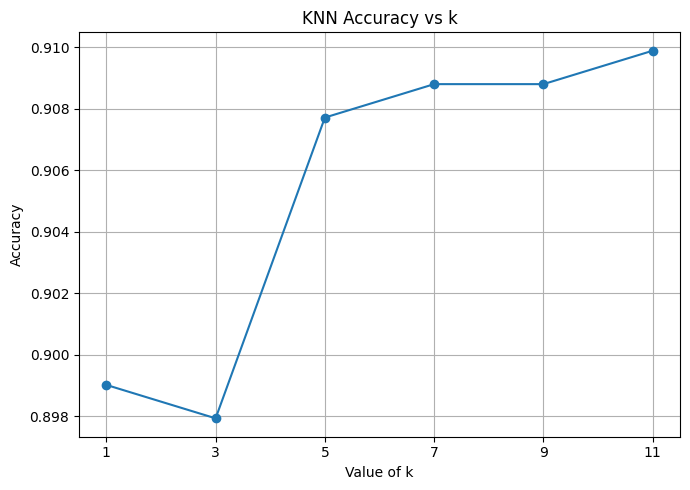


Best k: 11


In [ ]:
# ------------------------------------------------------------
# 13. Accuracy vs k
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    knn_results_df["k"],
    knn_results_df["Accuracy"],
    marker="o"
)

plt.xlabel("Value of k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()


# Find the best k based on accuracy.
best_k = knn_results_df.loc[
    knn_results_df["Accuracy"].idxmax(),
    "k"
]

print("\nBest k:", best_k)

In [ ]:

# Best KNN model

best_knn = KNeighborsClassifier(
    n_neighbors=int(best_k),
    weights="uniform",
    algorithm="auto"
)

start_time = time.perf_counter()
best_knn.fit(X_train_scaled, y_train)
best_knn_train_time = time.perf_counter() - start_time

start_time = time.perf_counter()

best_knn_pred = best_knn.predict(X_test_scaled)
best_knn_prob = best_knn.predict_proba(X_test_scaled)[:, 1]

best_knn_prediction_time = time.perf_counter() - start_time

print("\n================ Best KNN ================")

print(
    classification_report(
        y_test,
        best_knn_pred,
        target_names=["Ham", "Spam"]
    )
)


================ Best KNN ================
              precision    recall  f1-score   support

         Ham       0.92      0.94      0.93       558
        Spam       0.90      0.87      0.88       363

    accuracy                           0.91       921
   macro avg       0.91      0.90      0.91       921
weighted avg       0.91      0.91      0.91       921



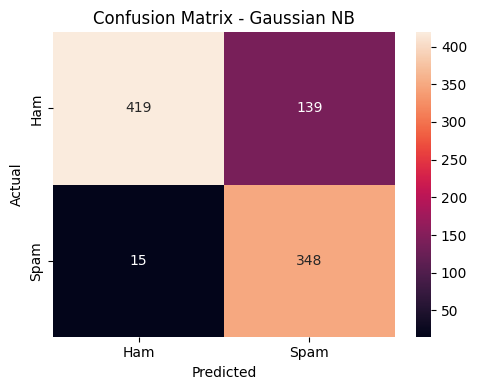

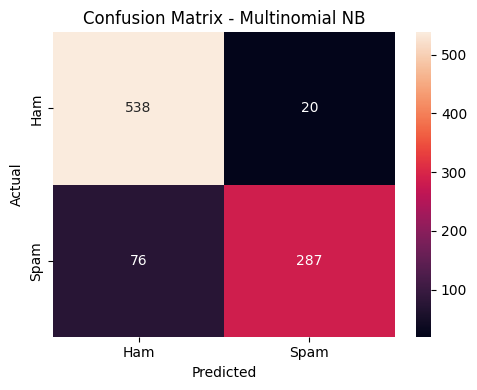

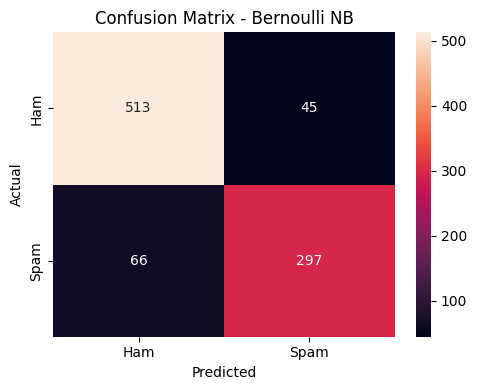

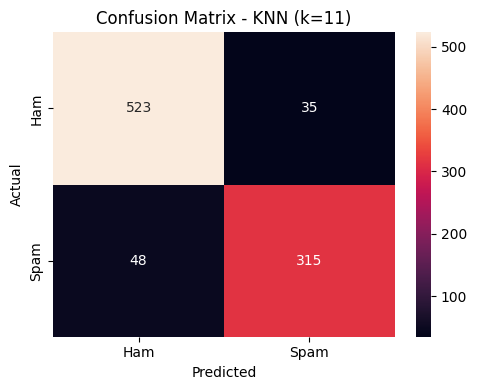

In [ ]:
# Confusion matrices
model_predictions = {
    "Gaussian NB": gaussian_pred,
    "Multinomial NB": multinomial_pred,
    "Bernoulli NB": bernoulli_pred,
    f"KNN (k={best_k})": best_knn_pred
}

for name, predictions in model_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Ham", "Spam"],
        yticklabels=["Ham", "Spam"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

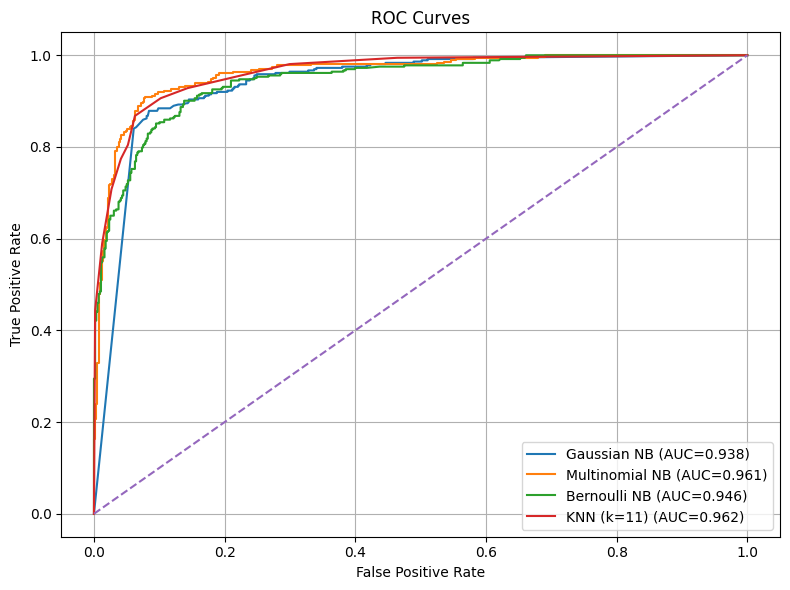

In [ ]:
# ============================================================
# 16. ROC Curves
# ============================================================

model_probabilities = {
    "Gaussian NB": gaussian_prob,
    "Multinomial NB": multinomial_prob,
    "Bernoulli NB": bernoulli_prob,
    f"KNN (k={best_k})": best_knn_prob
}

plt.figure(figsize=(8, 6))

for name, probabilities in model_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_value = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

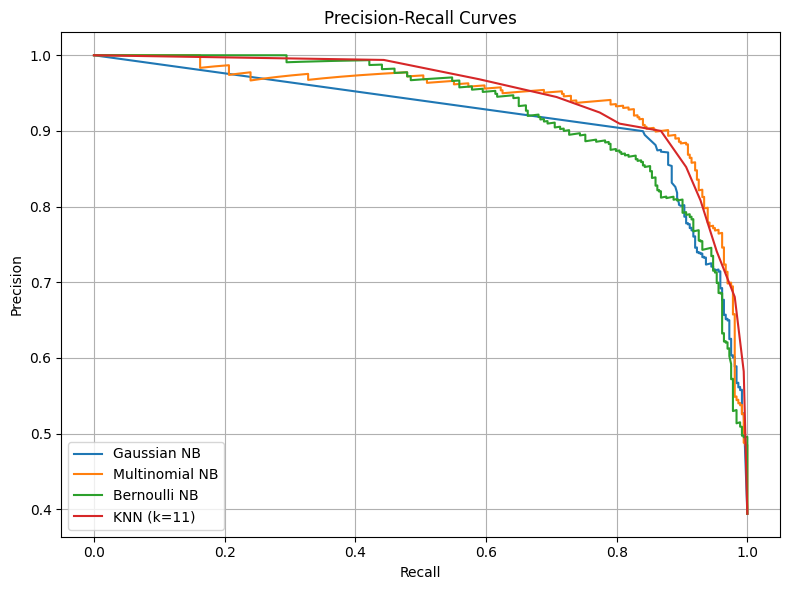

In [ ]:
#Precision-Recall Curves

plt.figure(figsize=(8, 6))

for name, probabilities in model_probabilities.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

#GridSearchCV for KNN

# A pipeline ensures that scaling is performed separately
# inside each cross-validation fold.
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

parameter_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__algorithm": ["auto", "kd_tree", "ball_tree"],
    "knn__p": [1, 2]
}

start_time = time.perf_counter()

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=parameter_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X, y)

grid_time = time.perf_counter() - start_time

print("\n================ GridSearchCV ================")
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)
print("Execution time:", grid_time)


================ GridSearchCV ================
Best parameters: {'knn__algorithm': 'auto', 'knn__n_neighbors': 7, 'knn__p': 1, 'knn__weights': 'distance'}
Best CV accuracy: 0.9000254921399236
Execution time: 134.82488588400003


In [ ]:
#RandomizedSearchCV

from scipy.stats import randint

random_parameter_grid = {
    "knn__n_neighbors": randint(1, 20),
    "knn__weights": ["uniform", "distance"],
    "knn__algorithm": ["auto", "kd_tree", "ball_tree"],
    "knn__p": [1, 2]
}

start_time = time.perf_counter()

random_search = RandomizedSearchCV(
    estimator=knn_pipeline,
    param_distributions=random_parameter_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X, y)

random_time = time.perf_counter() - start_time

print("\n================ RandomizedSearchCV ================")
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy:", random_search.best_score_)
print("Execution time:", random_time)


================ RandomizedSearchCV ================
Best parameters: {'knn__algorithm': 'kd_tree', 'knn__n_neighbors': 18, 'knn__p': 2, 'knn__weights': 'distance'}
Best CV accuracy: 0.9004569702119625
Execution time: 26.157758647000037


In [ ]:

#KDTree vs BallTree
tree_results = []

for algorithm in ["kd_tree", "ball_tree"]:

    tree_knn = Pipeline([
        ("scaler", StandardScaler()),
        (
            "knn",
            KNeighborsClassifier(
                n_neighbors=int(best_k),
                algorithm=algorithm
            )
        )
    ])

    start_time = time.perf_counter()

    tree_knn.fit(X_train, y_train)

    training_time = time.perf_counter() - start_time

    start_time = time.perf_counter()

    tree_pred = tree_knn.predict(X_test)

    prediction_time = time.perf_counter() - start_time

    tree_accuracy = accuracy_score(
        y_test,
        tree_pred
    )

    tree_results.append({
        "Algorithm": algorithm,
        "Accuracy": tree_accuracy,
        "Training Time": training_time,
        "Prediction Time": prediction_time
    })


tree_results_df = pd.DataFrame(tree_results)

print("\n================ KDTree vs BallTree ================")
print(tree_results_df.to_string(index=False))



================ KDTree vs BallTree ================
Algorithm  Accuracy  Training Time  Prediction Time
  kd_tree  0.909881       0.038629         0.329003
ball_tree  0.909881       0.026792         0.319200



================ Five Fold Cross Validation ================
Naive Bayes fold accuracies:
[0.82084691 0.80869565 0.80108696 0.82173913 0.825     ]
Naive Bayes average accuracy: 0.8154737289335788

KNN fold accuracies:
[0.90228013 0.90652174 0.92065217 0.90869565 0.8923913 ]
KNN average accuracy: 0.9061081999716754


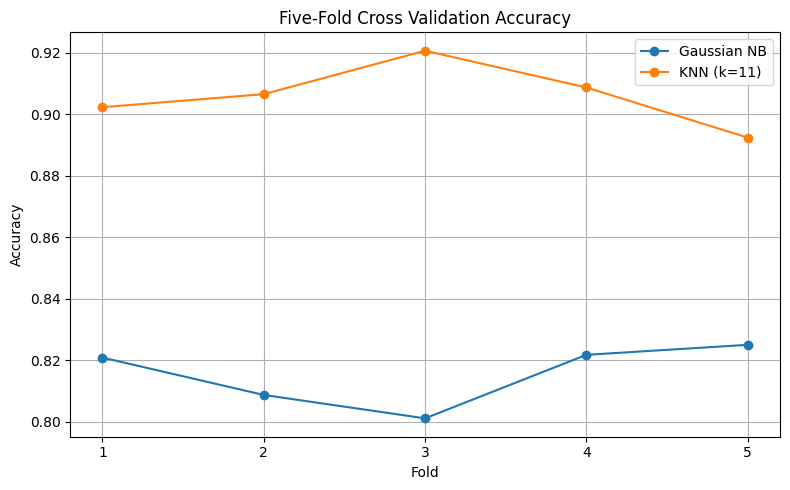

In [ ]:


# ============================================================
# 21. Five-fold Cross Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

# Best Naive Bayes model based on test accuracy.
best_nb_name = nb_results_df.loc[
    nb_results_df["Accuracy"].idxmax(),
    "Model"
]

best_nb_model = nb_models[best_nb_name]

# For simplicity, use the already scaled data for NB CV.
# Gaussian NB is evaluated on standardized features.
nb_cv_scores = cross_val_score(
    GaussianNB(),
    scaler.fit_transform(X),
    y,
    cv=cv,
    scoring="accuracy"
)

# Evaluate the selected KNN for each fold.
knn_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "knn",
        KNeighborsClassifier(
            n_neighbors=int(best_k)
        )
    )
])

knn_cv_scores = cross_val_score(
    knn_cv_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\n================ Five Fold Cross Validation ================")

print("Naive Bayes fold accuracies:")
print(nb_cv_scores)

print("Naive Bayes average accuracy:",
      nb_cv_scores.mean())

print("\nKNN fold accuracies:")
print(knn_cv_scores)

print("KNN average accuracy:",
      knn_cv_scores.mean())


# Plot CV accuracy.
plt.figure(figsize=(8, 5))

fold_numbers = [1, 2, 3, 4, 5]

plt.plot(
    fold_numbers,
    nb_cv_scores,
    marker="o",
    label="Gaussian NB"
)

plt.plot(
    fold_numbers,
    knn_cv_scores,
    marker="o",
    label=f"KNN (k={best_k})"
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Five-Fold Cross Validation Accuracy")
plt.xticks(fold_numbers)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


================ Experimental Time Analysis ================
     Algorithm  Training Time  Prediction Time
   Gaussian NB       0.037629         0.020833
Multinomial NB       0.017249         0.012878
  Bernoulli NB       0.024530         0.012228
    KNN (k=11)       0.010339         0.220691


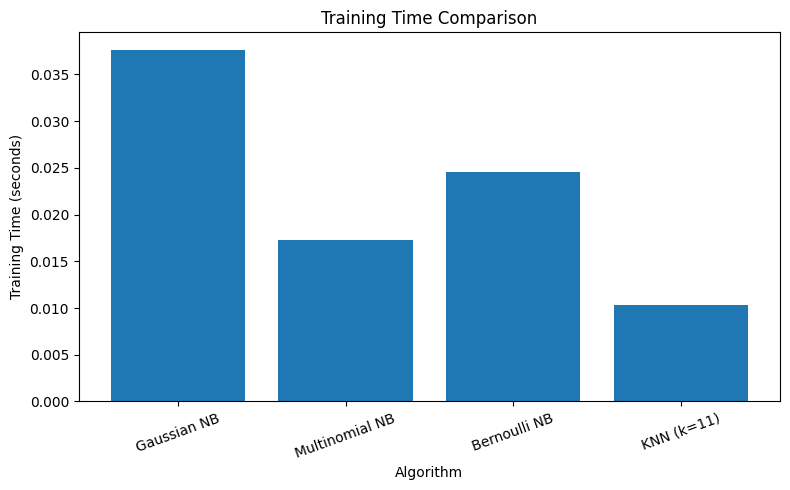

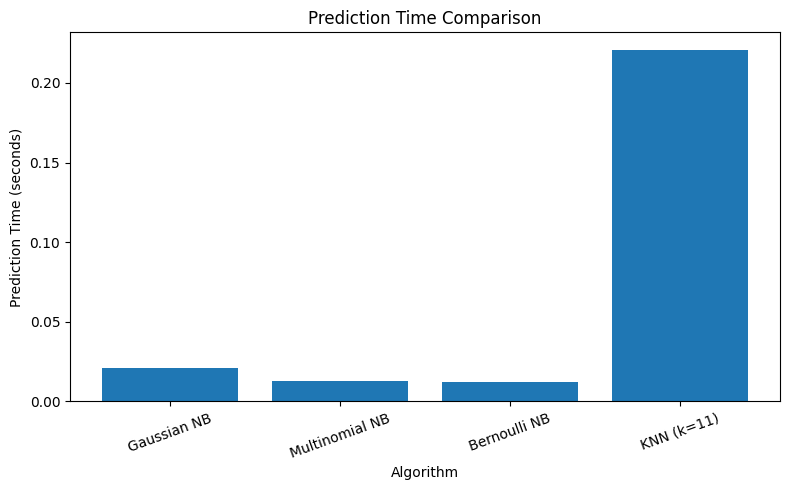

In [ ]:
# ============================================================
# 22. Training and prediction time comparison
# ============================================================

time_results = pd.DataFrame({
    "Algorithm": [
        "Gaussian NB",
        "Multinomial NB",
        "Bernoulli NB",
        f"KNN (k={best_k})"
    ],
    "Training Time": [
        gaussian_train_time,
        multinomial_train_time,
        bernoulli_train_time,
        best_knn_train_time
    ],
    "Prediction Time": [
        gaussian_prediction_time,
        multinomial_prediction_time,
        bernoulli_prediction_time,
        best_knn_prediction_time
    ]
})

print("\n================ Experimental Time Analysis ================")
print(time_results.to_string(index=False))


# Training time plot
plt.figure(figsize=(8, 5))

plt.bar(
    time_results["Algorithm"],
    time_results["Training Time"]
)

plt.xlabel("Algorithm")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# Prediction time plot
plt.figure(figsize=(8, 5))

plt.bar(
    time_results["Algorithm"],
    time_results["Prediction Time"]
)

plt.xlabel("Algorithm")
plt.ylabel("Prediction Time (seconds)")
plt.title("Prediction Time Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


================ Overall Classifier Comparison ================
         Model  Accuracy  Precision   Recall       F1  ROC-AUC
   Gaussian NB  0.832790   0.714579 0.958678 0.818824 0.937612
Multinomial NB  0.895765   0.934853 0.790634 0.856716 0.961191
  Bernoulli NB  0.879479   0.868421 0.818182 0.842553 0.945674
    KNN (k=11)  0.909881   0.900000 0.867769 0.883590 0.962173


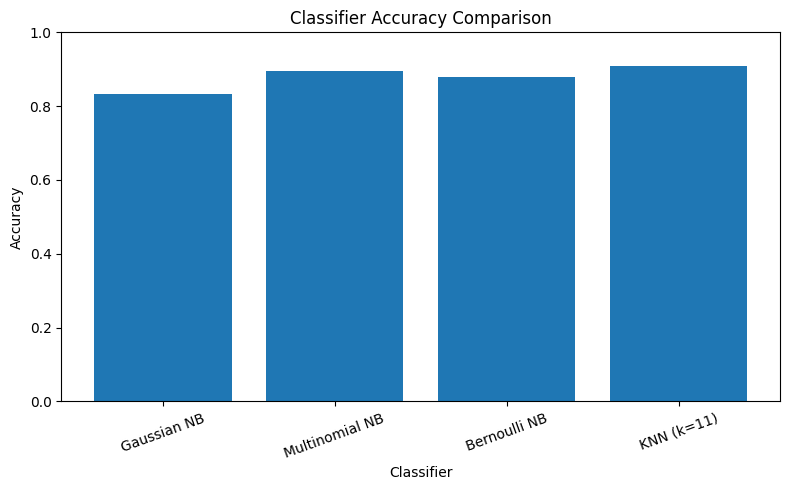

In [ ]:
# ============================================================
# 23. Overall classifier comparison
# ============================================================

comparison_df = nb_results_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
].copy()

knn_best_row = pd.DataFrame([{
    "Model": f"KNN (k={best_k})",
    "Accuracy": accuracy_score(y_test, best_knn_pred),
    "Precision": precision_score(y_test, best_knn_pred),
    "Recall": recall_score(y_test, best_knn_pred),
    "F1": f1_score(y_test, best_knn_pred),
    "ROC-AUC": roc_auc_score(y_test, best_knn_prob)
}])

comparison_df = pd.concat(
    [comparison_df, knn_best_row],
    ignore_index=True
)

print("\n================ Overall Classifier Comparison ================")
print(comparison_df.to_string(index=False))


# Plot overall accuracy comparison.
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.xlabel("Classifier")
plt.ylabel("Accuracy")
plt.title("Classifier Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 24. Save important results
# ============================================================

nb_results_df.to_csv(
    "naive_bayes_results.csv",
    index=False
)

knn_results_df.to_csv(
    "knn_results.csv",
    index=False
)

tree_results_df.to_csv(
    "tree_results.csv",
    index=False
)

time_results.to_csv(
    "time_results.csv",
    index=False
)

comparison_df.to_csv(
    "classifier_comparison.csv",
    index=False
)